In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

## The model

In [33]:
target_map = {"Active": 0, "Voluntarily Terminated": 1}

df_filtered = df[df["EmploymentStatus"].isin(target_map)].copy()
df_filtered["Target"] = df_filtered["EmploymentStatus"].map(target_map)

features = [
    "CarOpp", "OrgIden", "ProjSelf", "Trust", "ProjColl",
    "TeamIden", "ProjLead", "AIConf", "PsySafe", "Feedback",
    "Network", "AIUse", "SpecialProjectsCount", "TechLev",
    "ManPos", "InnoCont", "TrainHours", "PerfScore", "Salary",
    "MaritalDesc", "RaceDesc", "RecruitmentSource", "Remote"
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

model_pipeline.fit(X_train, y_train)

coefs = model_pipeline.named_steps["classifier"].coef_[0]

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs
    })
    .sort_values("Coefficient", ascending=False)
)

active_users = X[y == 0]

flight_risk_probs = model_pipeline.predict_proba(active_users)[:, 1]

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f}")

print(importance_df.head(10))

risk_table = (
    pd.DataFrame({
        "Employee_Index": active_users.index,
        "Flight_Risk_Probability": flight_risk_probs
    })
    .sort_values("Flight_Risk_Probability", ascending=False)
)

print(risk_table.head(5))

5-Fold CV Accuracy: 0.8728
                                      Feature  Coefficient
17                                  PerfScore     0.835498
15                                   InnoCont     0.608995
11                                      AIUse     0.485219
33  RecruitmentSource_On-line Web application     0.420763
37                             Remote_On-site     0.398290
36                              Remote_Hybrid     0.344813
10                                    Network     0.329143
16                                 TrainHours     0.318287
30            RecruitmentSource_Google Search     0.233437
27                             RaceDesc_White     0.205264
     Employee_Index  Flight_Risk_Probability
15               23                 0.988888
50               69                 0.970494
195             288                 0.954268
80              111                 0.951967
157             230                 0.907594


## Model validation

In [34]:
target_map = {"Active": 0, "Voluntarily Terminated": 1}

df_filtered = df[df["EmploymentStatus"].isin(target_map)].copy()
df_filtered["Target"] = df_filtered["EmploymentStatus"].map(target_map)

features = [
    "CarOpp", "OrgIden", "ProjSelf", "Trust", "ProjColl",
    "TeamIden", "ProjLead", "AIConf", "PsySafe", "Feedback",
    "Network", "AIUse", "SpecialProjectsCount", "TechLev",
    "ManPos", "InnoCont", "TrainHours", "PerfScore", "Salary",
    "MaritalDesc", "RaceDesc", "RecruitmentSource", "Remote"
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered["Target"]

test_count = 20
test_ratio = test_count / len(df_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    stratify=y,
    random_state=42
)

model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

model_pipeline.fit(X_train, y_train)

print("Mean Accuracy:", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1:", cv_results["test_f1"].mean())

coefs = model_pipeline.named_steps["classifier"].coef_[0]

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": coefs
    })
    .sort_values("Coefficient", ascending=False)
)

test_probs = model_pipeline.predict_proba(X_test)[:, 1]

risk_report_20 = pd.DataFrame(
    {
        "Actual_Status": y_test.map({0: "Active", 1: "Voluntarily Terminated"}).values,
        "Leaving_Probability": test_probs
    },
    index=X_test.index
)

if "Employee.Name" in df.columns:
    risk_report_20.insert(
        0,
        "Employee_Name",
        df.loc[X_test.index, "Employee.Name"].values
    )

print(risk_report_20.sort_values("Leaving_Probability", ascending=False))

y_test_pred = model_pipeline.predict(X_test)

print(classification_report(y_test, y_test_pred))

Mean Accuracy: 0.8800000000000001
Mean Precision: 0.7923137254901962
Mean Recall: 0.8441176470588235
Mean F1: 0.8093341488658978
             Employee_Name           Actual_Status  Leaving_Probability
247          Sadki, Nore    Voluntarily Terminated             0.984421
256       Sloan, Constance  Voluntarily Terminated             0.908976
188            Miller, Ned  Voluntarily Terminated             0.902230
218     Peterson, Ebonee    Voluntarily Terminated             0.800051
147        Kampew, Donysha  Voluntarily Terminated             0.669557
304     Winthrop, Jordan    Voluntarily Terminated             0.610154
139     Jackson, Maryellen                  Active             0.465409
165       Lecter, Hannibal                  Active             0.409136
172         Lunquist, Lisa                  Active             0.201665
98          Fraval, Maruk                   Active             0.060523
274          Szabo, Andrew                  Active             0.057758
22     

## Result interpretation

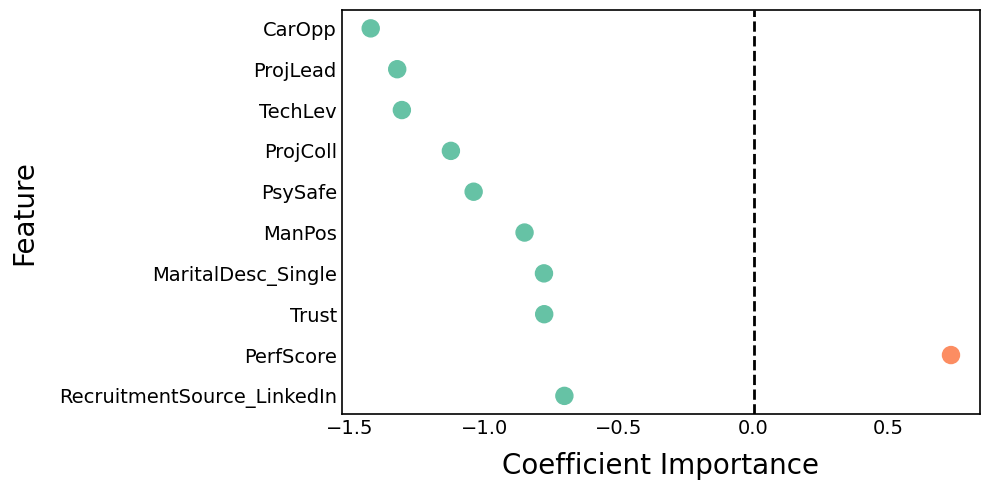

In [35]:
importance_df['Magnitude'] = importance_df['Coefficient'].abs()
top_10_features = importance_df.nlargest(10, 'Magnitude').iloc[::-1]

palette = sns.color_palette("Set2", n_colors=2)

colors = top_10_features['Coefficient'].apply(lambda x: palette[1] if x >= 0 else palette[0])

plt.figure(figsize=(10, 5))
plt.scatter(
    x=top_10_features['Coefficient'],
    y=top_10_features['Feature'],
    s=150,
    c=colors.values
)

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=14)
ax.tick_params(axis='y', length=0, labelsize=14)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.xlabel('Coefficient Importance', fontsize=20, labelpad=10)
plt.ylabel('Feature', fontsize=20, labelpad=15)
plt.axvline(x=0, color='black', lw=2, linestyle='--')

plt.tight_layout()
plt.show()

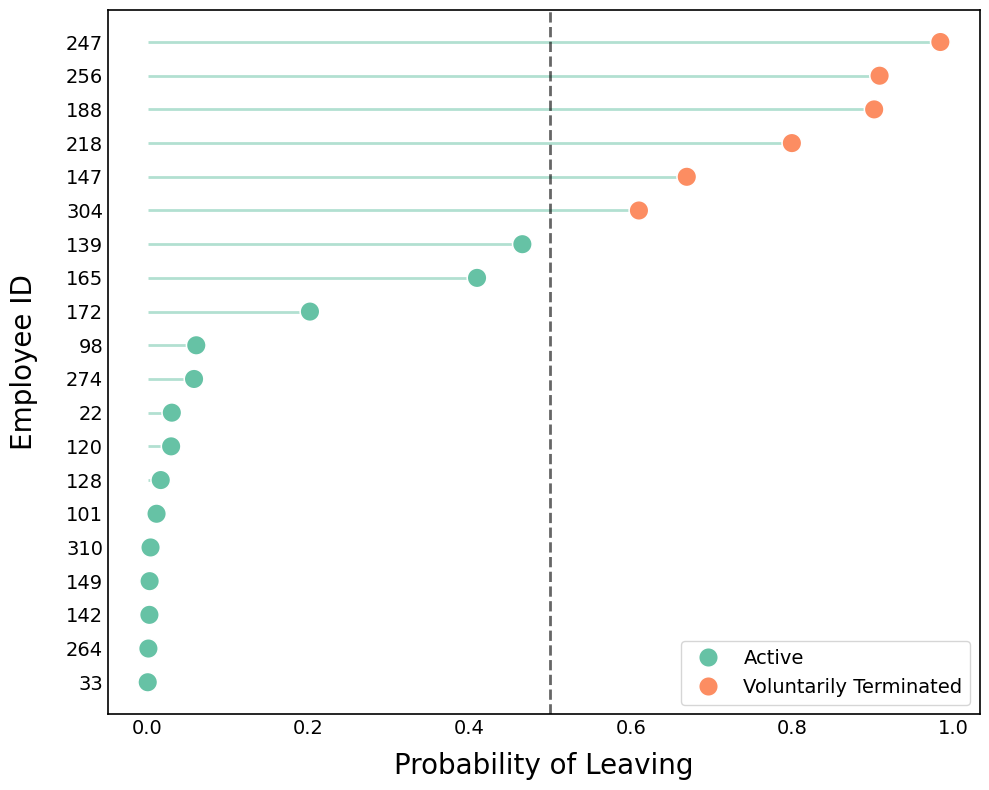

In [36]:
plot_df = risk_report_20.sort_values('Leaving_Probability', ascending=True).reset_index()
plot_df.rename(columns={'index': 'Employee_ID'}, inplace=True)

plt.figure(figsize=(10, 8))

plt.hlines(
    y=range(len(plot_df)),
    xmin=0,
    xmax=plot_df['Leaving_Probability'],
    color=palette[0],
    alpha=0.5,
    linewidth=2
)

sns.scatterplot(
    x='Leaving_Probability',
    y=range(len(plot_df)),
    hue='Actual_Status',
    data=plot_df,
    palette={'Active': palette[0], 'Voluntarily Terminated': palette[1]},
    s=200,
    zorder=3
)

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=14)
ax.tick_params(axis='y', length=0, labelsize=14)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.yticks(range(len(plot_df)), plot_df['Employee_ID'])

plt.xlabel('Probability of Leaving', fontsize=20, labelpad=10)
plt.ylabel('Employee ID', fontsize=20, labelpad=20)

plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.6, linewidth=2)

plt.legend(loc='lower right', fontsize=14)
plt.tight_layout()
plt.show()

### RISK ASSESSMENT: 48 ACTIVE TALENT EMPLOYEES

Q1 (25th Percentile):    0.15%
Q3 (75th Percentile):    3.96%
IQR:                     3.81%
OUTLIER THRESHOLD:       9.67%


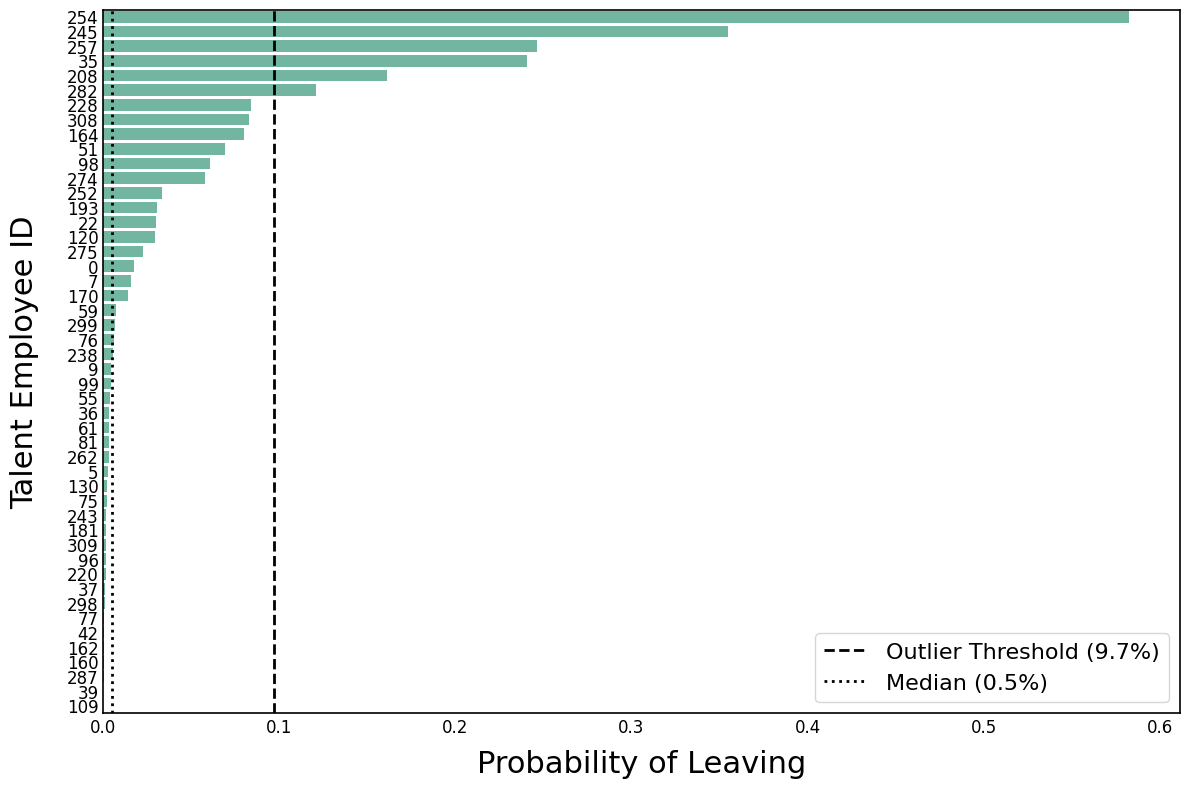

In [37]:
active_talent_df = df[(df['is_talent'] == 1) & (df['EmploymentStatus'] == 'Active')].copy()

X_active = pd.get_dummies(active_talent_df[features], drop_first=True)
X_active = X_active.reindex(columns=X.columns, fill_value=0)

active_probs = model_pipeline.predict_proba(X_active)[:, 1]

active_risk_report = pd.DataFrame({
    'Employee_ID': active_talent_df.index.astype(str),
    'Leaving_Probability': active_probs
})

Q1 = active_risk_report['Leaving_Probability'].quantile(0.25)
Q3 = active_risk_report['Leaving_Probability'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + (1.5 * IQR)

print(f"### RISK ASSESSMENT: {len(active_risk_report)} ACTIVE TALENT EMPLOYEES")

print("\n" + "="*45)
print(f"Q1 (25th Percentile):    {Q1:.2%}")
print(f"Q3 (75th Percentile):    {Q3:.2%}")
print(f"IQR:                     {IQR:.2%}")
print(f"OUTLIER THRESHOLD:       {outlier_threshold:.2%}")
print("="*45)

plt.figure(figsize=(12, 8))

plot_data = active_risk_report.sort_values('Leaving_Probability', ascending=False)

sns.barplot(
    x='Leaving_Probability',
    y='Employee_ID',
    data=plot_data,
    color=palette[0]
)

plt.axvline(outlier_threshold, color='black', linestyle='--', linewidth=2,
            label=f'Outlier Threshold ({outlier_threshold:.1%})')

median_val = active_risk_report['Leaving_Probability'].median()
plt.axvline(median_val, color='black', linestyle=':', linewidth=2,
            label=f'Median ({median_val:.1%})')

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.tick_params(axis='y', length=0, labelsize=12)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.xlabel('Probability of Leaving', fontsize=22, labelpad=10)
plt.ylabel('Talent Employee ID', fontsize=22, labelpad=20)
plt.legend(loc='lower right', fontsize=16)

plt.tight_layout()
plt.show()

In [38]:
active_risk_report['Department'] = active_talent_df['Department'].values
top_6_risk = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)
top_6_risk['Is_Outlier'] = top_6_risk['Leaving_Probability'] > outlier_threshold

print("### TOP 6 HIGHEST RISK TALENTS BY SECTOR")
print(top_6_risk[['Employee_ID', 'Department', 'Leaving_Probability', 'Is_Outlier']].to_string(index=False))
print("\n### SECTOR CONCENTRATION (TOP 6)")
print(top_6_risk['Department'].value_counts())

### TOP 6 HIGHEST RISK TALENTS BY SECTOR
Employee_ID           Department  Leaving_Probability  Is_Outlier
        254                IT/IS             0.582467        True
        245 Software Engineering             0.354674        True
        257           Production             0.246323        True
         35 Software Engineering             0.240593        True
        208           Production             0.161308        True
        282                Sales             0.120762        True

### SECTOR CONCENTRATION (TOP 6)
Department
Software Engineering    2
Production              2
IT/IS                   1
Sales                   1
Name: count, dtype: int64


In [39]:
top_6_ids = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)['Employee_ID'].tolist()

top_6_full_data = active_talent_df[active_talent_df.index.astype(str).isin(top_6_ids)].copy()

prob_map = active_risk_report.set_index('Employee_ID')['Leaving_Probability']

top_6_full_data['Risk_Score'] = top_6_full_data.index.astype(str).map(prob_map)
top_6_full_data = top_6_full_data.sort_values('Risk_Score', ascending=False)
top_6_full_data

,Employee.Name,PerfScore,PerformanceScore,GenderID,Salary,Termd,PositionID,Position,State,Zip,...,TrainHours,WLF,InnoCont,technical_score,personal_score,interpersonal_score,talent_score,is_talent,TalentStatus,Risk_Score
254,"Simard, Kramer",0.038401,Fully Meets,1,87826,0,9,Data Analyst,MA,2110,...,2.489807,0.862389,1.272193,0.965136,-0.060116,-0.015004,0.463788,1,Talent,0.582467
245,"Saada, Adell",0.038401,Fully Meets,0,86214,0,24,Software Engineer,MA,2132,...,1.139336,-0.373569,1.272193,0.787457,0.040328,-0.201055,0.353547,1,Talent,0.354674
257,"Smith, Joe",1.744516,Exceeds,1,60656,0,20,Production Technician II,MA,2045,...,1.199357,0.862389,1.272193,0.512485,0.225852,-0.064647,0.296543,1,Talent,0.246323
35,"Cady, Max",0.038401,Fully Meets,1,77692,0,25,Software Engineering Manager,MA,2184,...,0.719190,0.862389,0.135262,0.271055,0.079303,0.254919,0.219083,1,Talent,0.240593
208,"Osturnka, Adeel",1.744516,Exceeds,1,47414,0,19,Production Technician I,MA,2478,...,0.539127,-0.373569,2.409124,0.413665,0.208432,0.074185,0.277487,1,Talent,0.161308
282,"Torrence, Jack",1.744516,Exceeds,1,64397,0,3,Area Sales Manager,ND,58782,...,1.679525,-0.373569,2.409124,0.723407,0.204600,-0.105990,0.386356,1,Talent,0.120762


In [40]:
top_6_ids = active_risk_report.sort_values('Leaving_Probability', ascending=False).head(6)['Employee_ID'].tolist()
top_6_talents = active_talent_df[active_talent_df.index.astype(str).isin(top_6_ids)]
steady_talents = active_talent_df[~active_talent_df.index.astype(str).isin(top_6_ids)]

top_6_averages = top_6_talents.select_dtypes(include=[np.number]).mean()
steady_averages = steady_talents.select_dtypes(include=[np.number]).mean()

comparison_df = pd.DataFrame({
    'Steady_Talent_Avg': steady_averages,
    'Flight_Risk_Avg_Top_6': top_6_averages
})

comparison_df['Raw_Diff'] = comparison_df['Flight_Risk_Avg_Top_6'] - comparison_df['Steady_Talent_Avg']

comparison_df['Perc_Diff_%'] = (comparison_df['Raw_Diff'] / comparison_df['Steady_Talent_Avg']) * 100

comparison_df = comparison_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Perc_Diff_%'])

print(f"### COMPARISON: Steady Talents (n={len(steady_talents)}) vs. Flight Risk Talents (n=6)")
print(comparison_df.round(2))

print("\n### TOP 5 BIGGEST PERCENTAGE DROPS (Potential Flight Drivers):")
print(comparison_df.sort_values(by='Perc_Diff_%').head(5))

### COMPARISON: Steady Talents (n=42) vs. Flight Risk Talents (n=6)
                      Steady_Talent_Avg  Flight_Risk_Avg_Top_6  Raw_Diff  \
PerfScore                          0.57                   0.89      0.32   
GenderID                           0.52                   0.83      0.31   
Salary                         88102.05               70699.83 -17402.21   
PositionID                        15.07                  16.67      1.60   
Zip                             4597.24               11621.83   7024.60   
EngagementSurvey                   0.36                   0.02     -0.34   
EmpSatisfaction                    0.44                  -0.98     -1.42   
SpecialProjectsCount               1.30                   0.76     -0.54   
DaysLateLast30                    -0.28                  -0.32     -0.04   
Absences                           0.06                  -0.47     -0.53   
ManPos                             0.85                   0.19     -0.66   
TechLev             

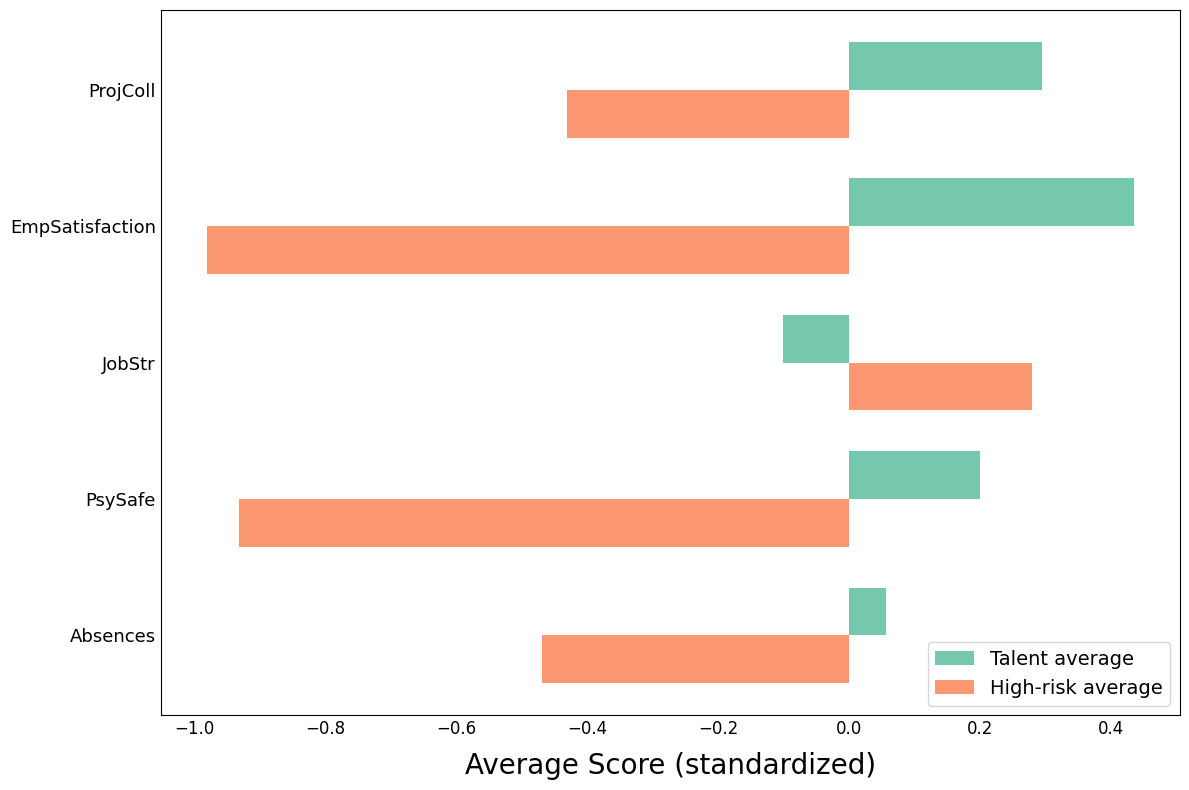

In [41]:
top_5_diffs = comparison_df.reindex(
    comparison_df['Perc_Diff_%'].abs().sort_values(ascending=False).index[:5]
).sort_values(by='Perc_Diff_%')

features_plot = top_5_diffs.index
steady_vals = top_5_diffs['Steady_Talent_Avg']
flight_risk_vals = top_5_diffs['Flight_Risk_Avg_Top_6']
perc_labels = top_5_diffs['Perc_Diff_%']

y_labels = [f"{feat}" for feat in features_plot]

y = np.arange(len(features_plot))
height = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(y + height/2, steady_vals, height, label='Talent average', color=palette[0], alpha=0.9)
ax.barh(y - height/2, flight_risk_vals, height, label='High-risk average', color=palette[1], alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=13)
ax.set_xlabel('Average Score (standardized)', fontsize=20, labelpad=10)
ax.legend(loc='lower right', fontsize=14)

for i, p_diff in enumerate(perc_labels):
    max_x = max(steady_vals.iloc[i], flight_risk_vals.iloc[i])
    label_color = 'grey'

ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.tick_params(axis='y', length=0, labelsize=13)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()